In [88]:
# Setup import path so local src modules are available
import os
import sys

sys.path.append(
    os.path.abspath("../src")
)
print("✓ Added ../src to Python path")

✓ Added ../src to Python path


In [89]:
# Load the NuScenes dataset for lidar-camera fusion
from data_loader import load_nuscenes

nusc = load_nuscenes()
print(f"✓ NuScenes loaded: {len(nusc.scene)} scenes")

Loading nuScenes from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.133 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
✓ NuScenes loaded: 10 scenes


In [90]:
# Select the first scene and retrieve camera/LiDAR sample metadata
scene = nusc.scene[0]

sample = nusc.get(
    "sample",
    scene["first_sample_token"]
)

cam_token = sample["data"]["CAM_FRONT"]
lidar_token = sample["data"]["LIDAR_TOP"]

cam_data = nusc.get(
    "sample_data",
    cam_token
)

lidar_data = nusc.get(
    "sample_data",
    lidar_token
)

print(f"✓ Scene: {scene['name']}")
print(f"✓ LiDAR token: {lidar_token}")
print(f"✓ Camera token: {cam_token}")

✓ Scene: scene-0061
✓ LiDAR token: 9d9bf11fb0e144c8b446d54a8a00184f
✓ Camera token: e3d495d4ac534d54b321f50006683844


In [91]:
# Load camera image and convert from BGR to RGB for display
import cv2

img_path = os.path.join(
    nusc.dataroot,
    cam_data["filename"]
)

image = cv2.imread(
    img_path
)
image = cv2.cvtColor(
    image,
    cv2.COLOR_BGR2RGB
)

print(f"✓ Loaded camera image from: {img_path}")
print(f"✓ Image shape: {image.shape}")

✓ Loaded camera image from: /Users/rana/Projects/autonomous-perception-stack/data/nuscenes/samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg
✓ Image shape: (900, 1600, 3)


In [92]:
# Run the perception pipeline to get object detections from the camera image
from perception.inference import (
    PerceptionPipeline
)

pipeline = (
    PerceptionPipeline()
)

detections = (
    pipeline.run(image)
)

print(f"✓ Detected {len(detections)} objects")

✓ Detected 7 objects


In [93]:
# Compute sensor calibration and project LiDAR points into the camera image frame
from geometry.calibration import (
    get_camera_calibration,
    get_lidar_calibration
)

from geometry.lidar_projection_pipeline import (
    run_lidar_projection_pipeline
)

cam_calib = (
    get_camera_calibration(
        nusc,
        cam_data
    )
)

lidar_calib = (
    get_lidar_calibration(
        nusc,
        lidar_data
    )
)

u, v, points_cam, pc = (
    run_lidar_projection_pipeline(
        nusc,
        lidar_data,
        lidar_calib,
        cam_calib
    )
)

print(f"✓ Projected {points_cam.shape[1]} LiDAR points into image plane")
print(f"✓ Camera and LiDAR calibration computed")

✓ Projected 34688 LiDAR points into image plane
✓ Camera and LiDAR calibration computed


In [94]:
# Fuse object detection masks with projected LiDAR points to produce fused object proposals
from fusion.mask_fusion import (
    fuse_masks_with_lidar
)

fused_objects = (
    fuse_masks_with_lidar(
        detections,
        u,
        v,
        points_cam,
        image.shape
    )
)

print(f"✓ Fused {len(fused_objects)} objects using mask and LiDAR information")

✓ Fused 7 objects using mask and LiDAR information


In [95]:
# Extract aggregated properties for each fused object
from fusion.object_extraction import (
    extract_object_properties
)

objects = (
    extract_object_properties(
        fused_objects
    )
)

print(f"✓ Extracted properties for {len(objects)} objects")

✓ Extracted properties for 7 objects


In [96]:
# Compute scene-level statistics from extracted object properties
from fusion.object_statistics import (
    generate_scene_statistics
)

stats = (
    generate_scene_statistics(
        objects
    )
)
print("✓ Scene statistics generated")
print(stats)
stats

✓ Scene statistics generated
{'object_counts': {'truck': 2, 'car': 3, 'bus': 1, 'bird': 1}, 'total_objects': 7, 'nearest_object_distance': 4.917990072913344}


{'object_counts': {'truck': 2, 'car': 3, 'bus': 1, 'bird': 1},
 'total_objects': 7,
 'nearest_object_distance': 4.917990072913344}

In [97]:
# Print summary information for the first few fused objects
print(f"✓ Reporting up to {min(10, len(objects))} fused objects")
for obj in objects[:10]:
    print(
        f"Class: {obj['class']}"
    )
    print(
        f"Distance: {obj['distance']:.2f} m"
    )
    print(
        f"Points: {obj['num_points']}"
    )
    print("-" * 40)

✓ Reporting up to 7 fused objects
Class: truck
Distance: 10.42 m
Points: 507
----------------------------------------
Class: car
Distance: 5.91 m
Points: 10
----------------------------------------
Class: bus
Distance: 7.26 m
Points: 17
----------------------------------------
Class: car
Distance: 4.92 m
Points: 5
----------------------------------------
Class: truck
Distance: 7.26 m
Points: 17
----------------------------------------
Class: bird
Distance: 6.40 m
Points: 13
----------------------------------------
Class: car
Distance: 7.26 m
Points: 17
----------------------------------------


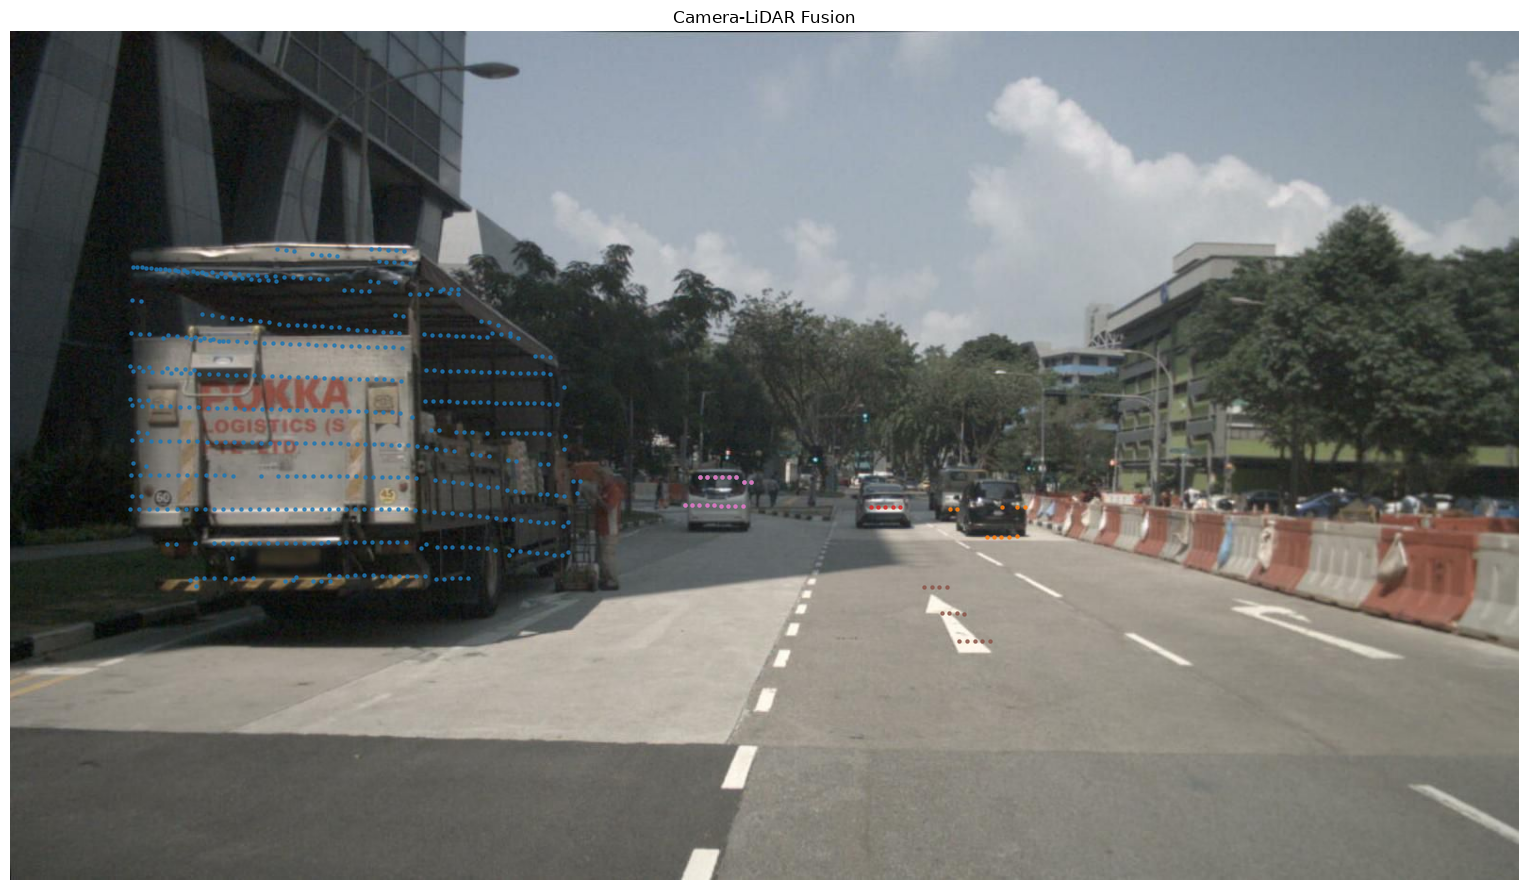

In [98]:
from visualization.fusion_view import (
    visualize_fusion
)

visualize_fusion(
    image,
    objects,
    save_path="../outputs/images/fusion_result.png"
)